In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("data/raw/Media-Matrix-Combined-v4-moles-per-litre-annotate.csv")
print(df.shape)

(62, 28)


In [4]:
# run this to remove these compounds from analysis
# filter rows that were considered not important

compounds_to_remove = [
    'Dipotassium phosphate', 'Disodium edta dihydrate', 'EDTA', 'Monopotassium phosphate',
    'Phosphoric acid', 'Potassium hydroxide', 'Sodium citrate dihydrate', 'Sodium phosphate',
    'Sulphuric acid', 'Uracil'
]
df = df[~df['Compound'].isin(compounds_to_remove)].copy()

print(df.shape)

(52, 28)


In [5]:
# remove pubchemid
df.drop(df.columns[1], axis=1, inplace=True)

In [6]:
# separate numeric columns for transformation
num_df = df.select_dtypes(include='number')

In [7]:
labels = df[['Compound', 'Annotate']]

In [8]:
pseudocount = 1e-10
num_df=np.log10(num_df.replace(0, pseudocount))


In [9]:
df_log = pd.concat([labels, num_df], axis=1)

In [10]:
yar_df = df_log.filter(like='_YAR')
cer_df = df_log.filter(like='_CER')
pic_df = df_log.filter(like='_PIC')

In [11]:
print(df_log.shape)
print(yar_df.shape)
print(cer_df.shape)     
print(pic_df.shape)

(52, 27)
(52, 10)
(52, 6)
(52, 9)


In [12]:
# labels are missing for individual dfs

yar_df.head()

,1_YAR,2a_YAR,2b_YAR,2c_YAR,2d_YAR,3a_YAR,3b_YAR,3c_YAR,4_YAR,5_YAR
0,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
1,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
2,-1.544693,-1.422064,-1.422064,-1.422064,-1.422064,-10.0,-1.518974,-1.467822,-1.422064,-1.217944
3,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
4,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000


In [13]:
df_long = pd.melt(df_log, id_vars=['Compound', 'Annotate'], var_name='Sample', value_name='Log10_Concentration')

In [14]:
# Add an 'Organism' column based on the suffix in 'Sample'
df_long['Organism'] = df_long['Sample'].str.extract(r'_([A-Z]+)$')


In [23]:
df_long['Annotate_Compound'] = df_long['Annotate'] + ' - ' + df_long['Compound']

ordered_x = sorted(df_long['Annotate_Compound'].unique()
                   )

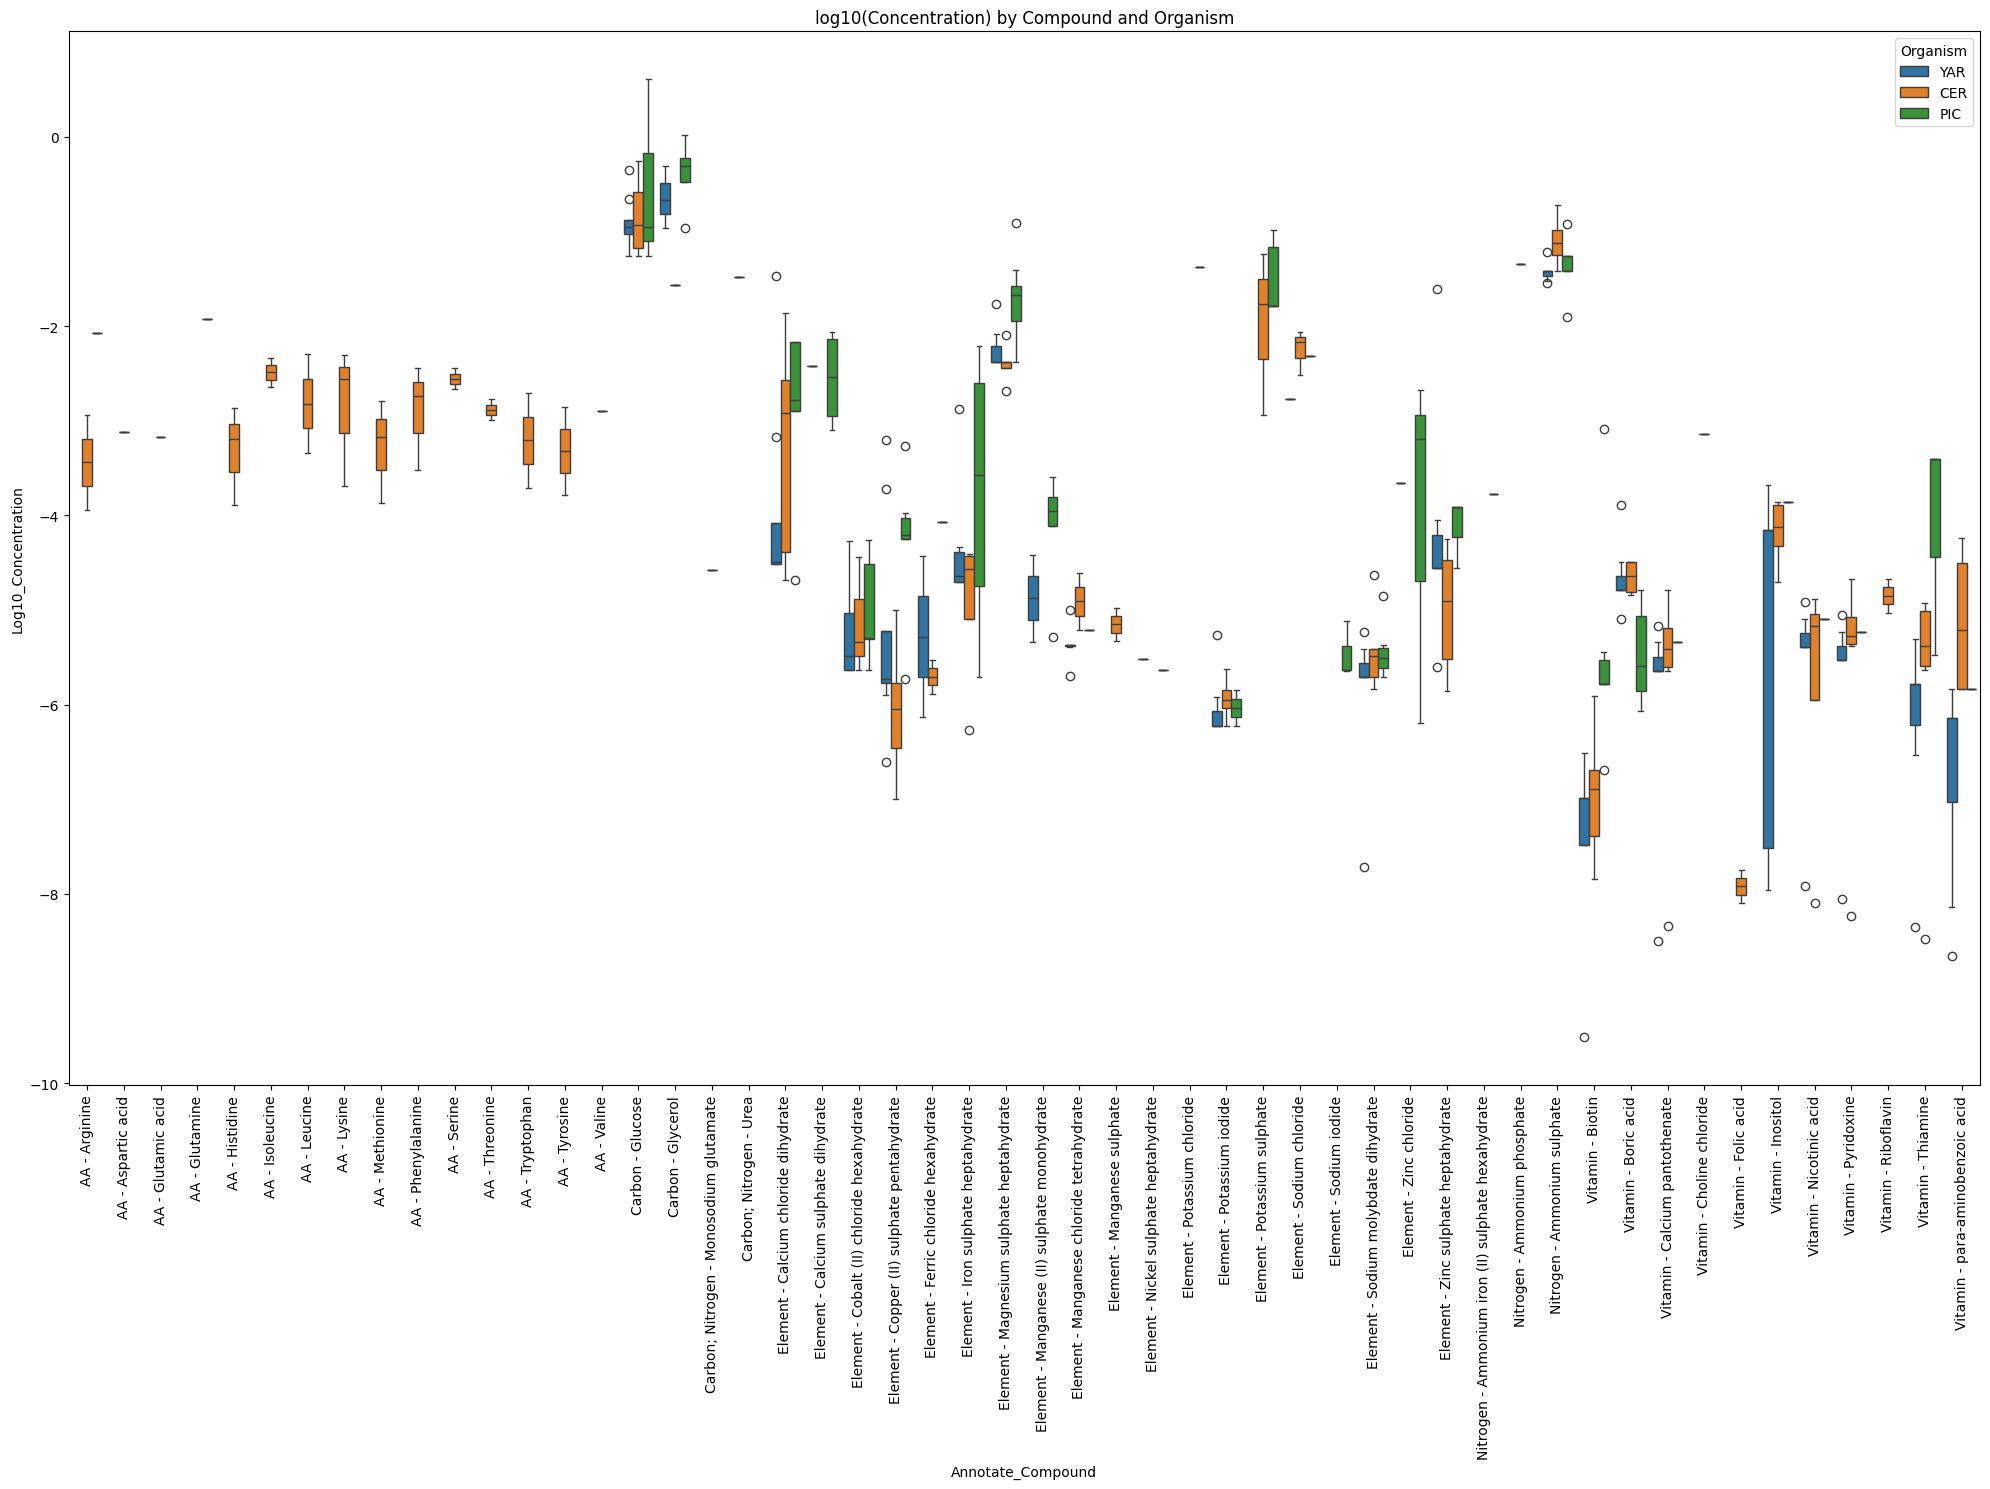

In [25]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df_long[df_long['Log10_Concentration'] > -10],  # exclude pseudocount
            x='Annotate_Compound', y='Log10_Concentration', hue='Organism', order=ordered_x)
plt.xticks(rotation=90)
plt.title('log10(Concentration) by Compound and Organism')
plt.tight_layout()
plt.show()

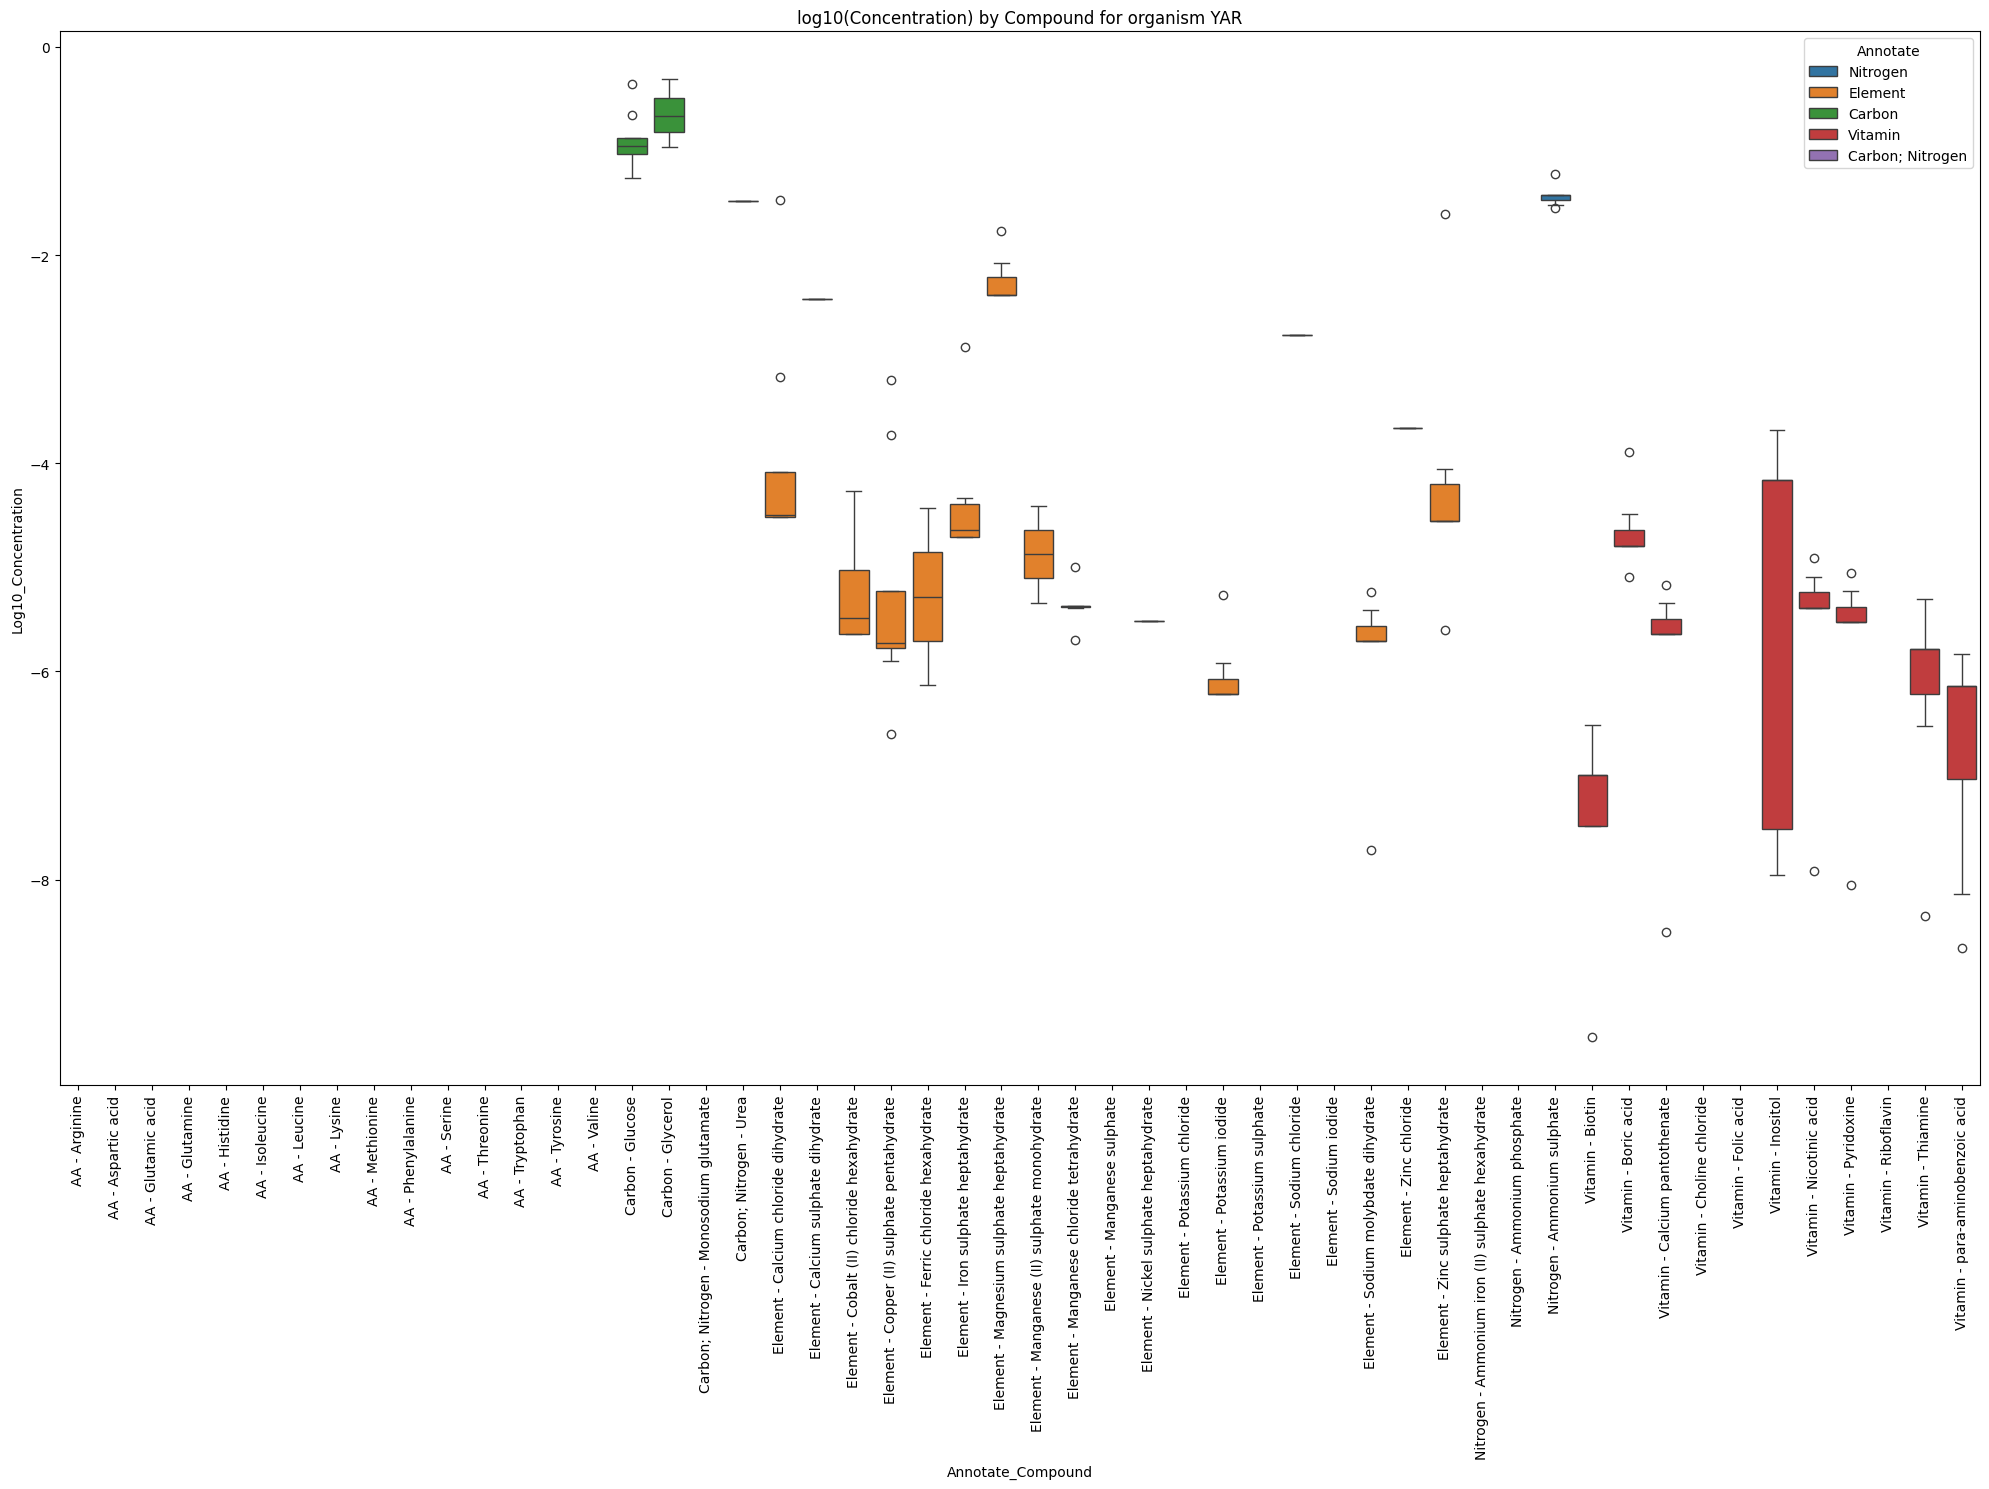

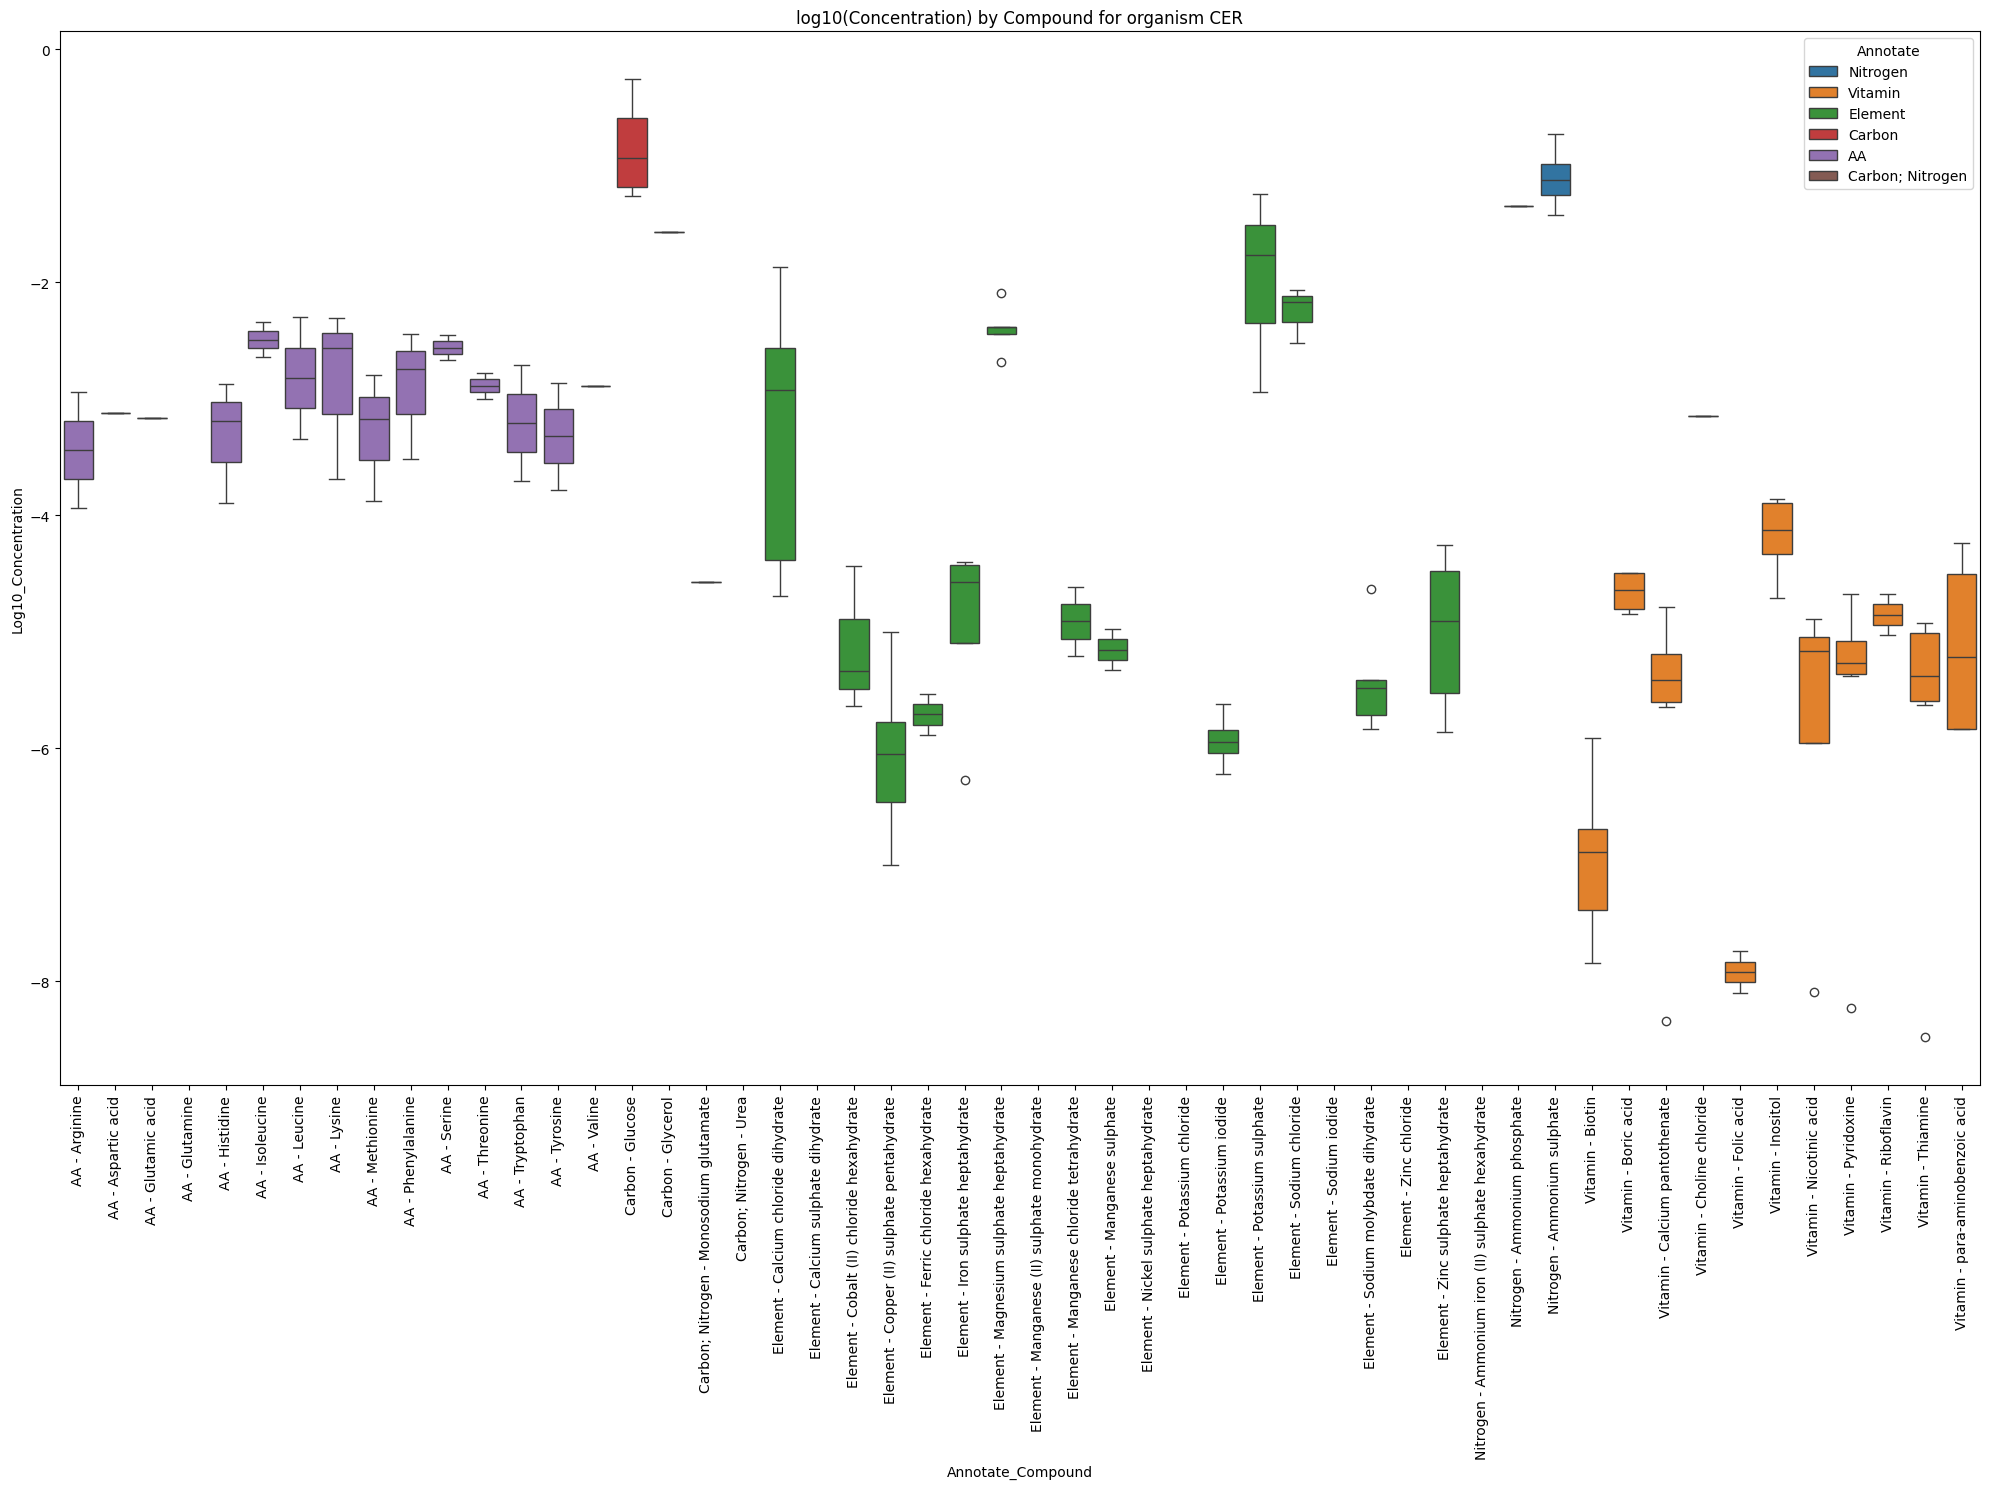

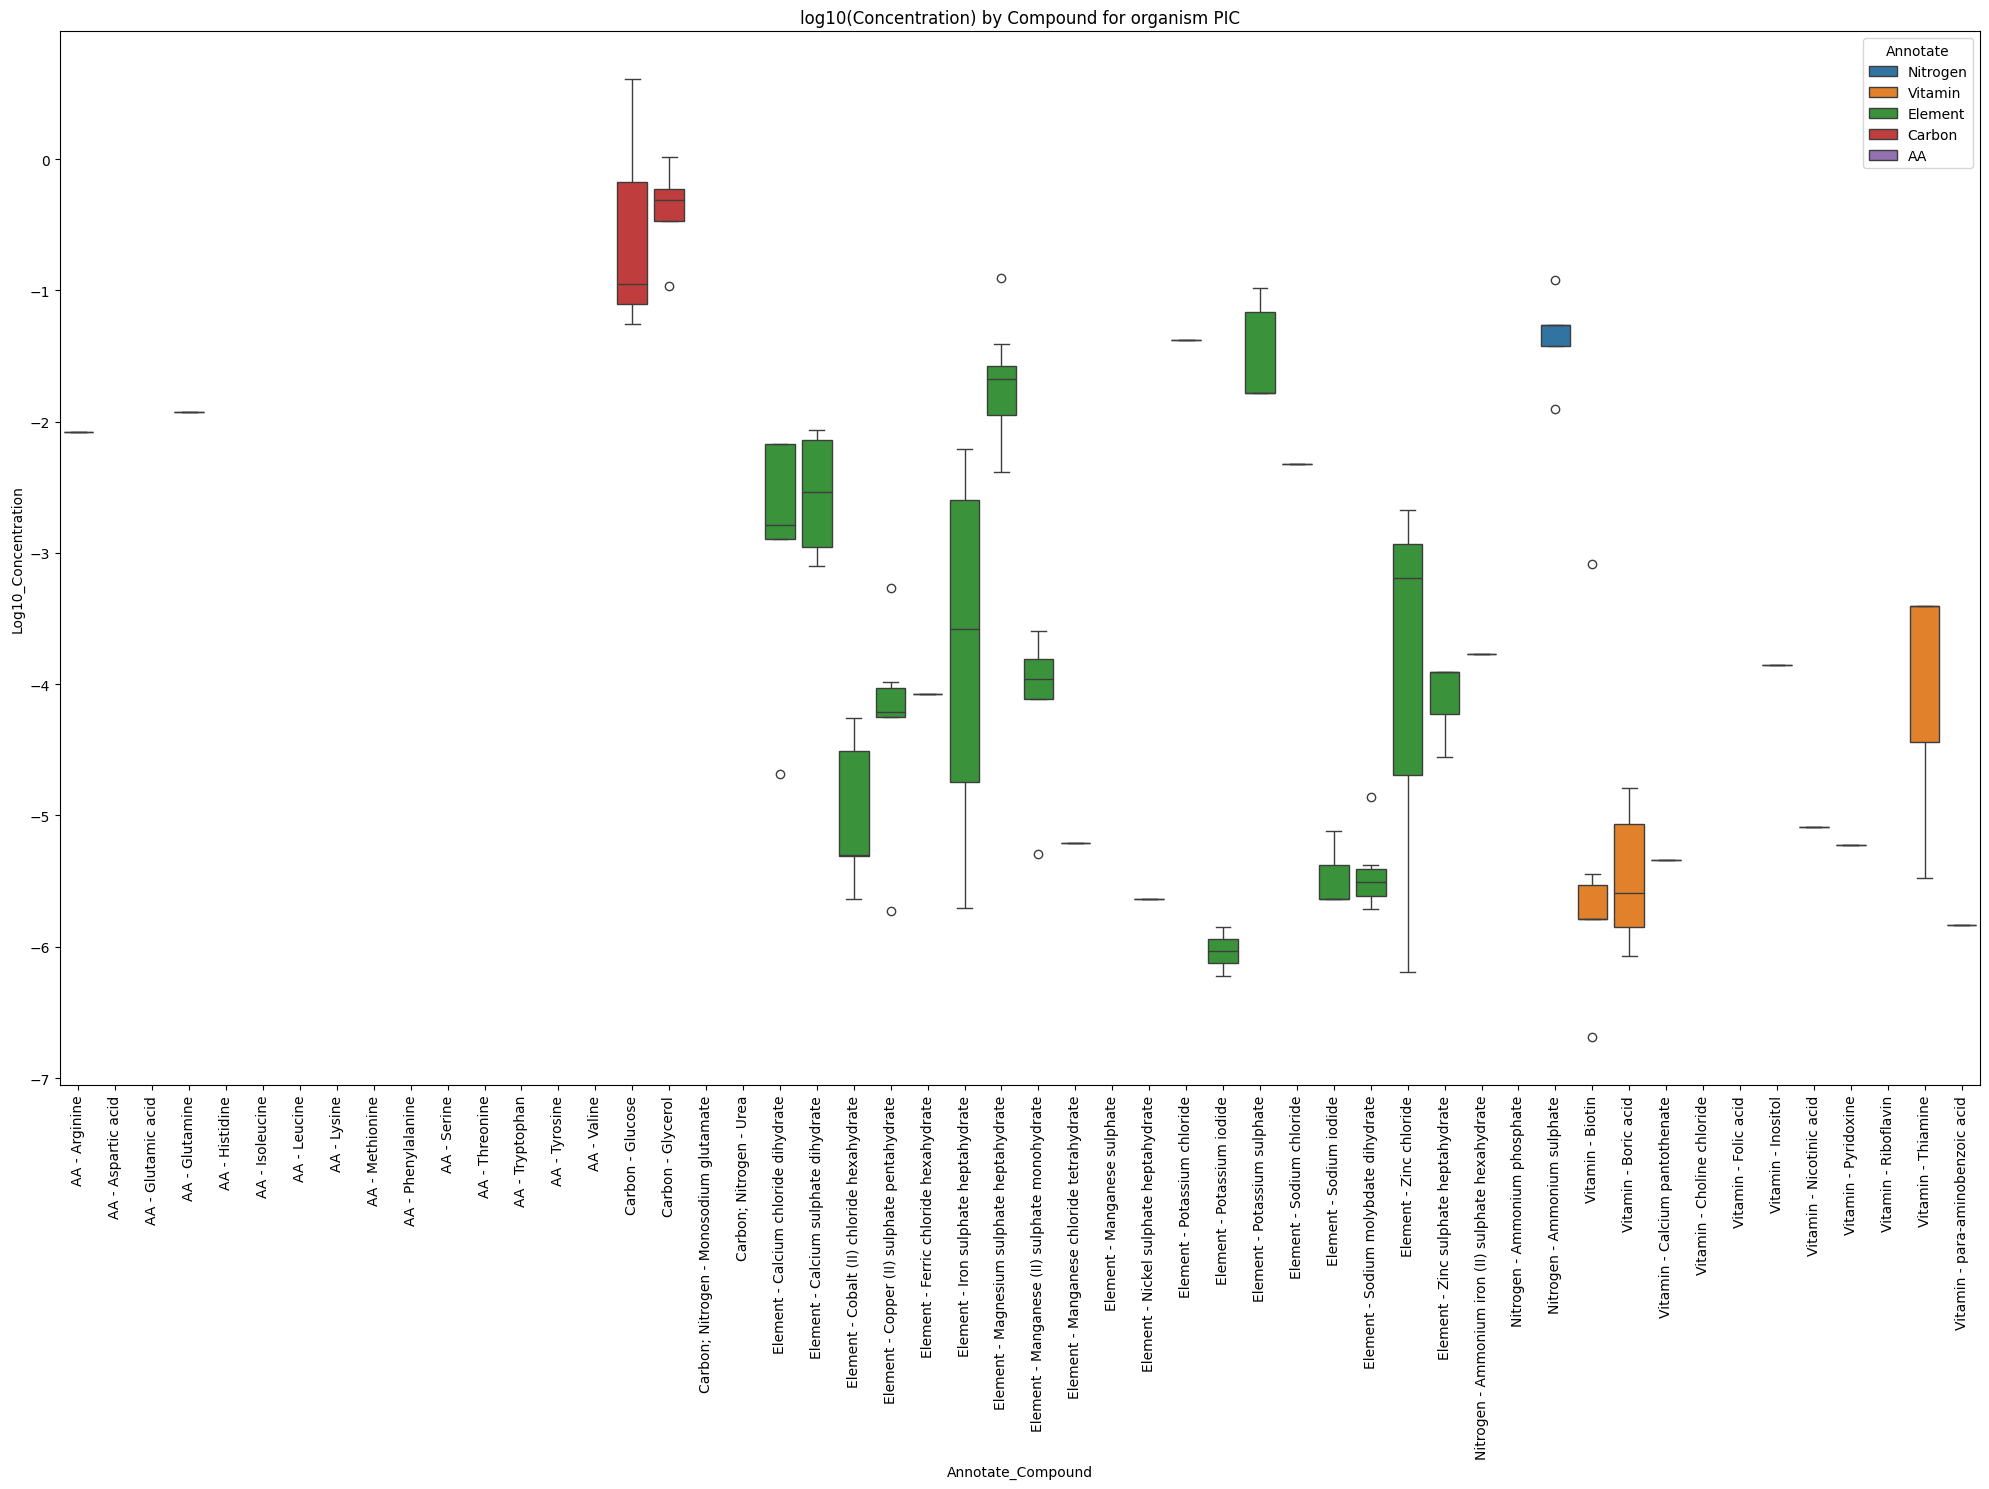

In [29]:
organisms = ['YAR', 'CER', 'PIC']

for org in organisms:
    plt.figure(figsize=(20, 15))
    subset = df_long[(df_long['Organism'] == org) & (df_long['Log10_Concentration'] > -10)]
    sns.boxplot(data=subset,
                x='Annotate_Compound', y='Log10_Concentration', hue = 'Annotate', order=ordered_x)
    plt.xticks(rotation=90)
    plt.title(f'log10(Concentration) by Compound for organism {org}')
    plt.tight_layout()
    plt.show()